# Custom CNN Character Model — Smart Prescription Error Detection

**Self-contained Google Colab notebook.**  
Run all cells top-to-bottom. GPU is optional for this model (it's small and fast even on CPU), but a T4 will make it near-instant.

## What this notebook does
1. Mounts Google Drive and loads your `data/characters/` letter dataset
2. Trains a lightweight CNN classifier on A-Z / a-z single-letter images
3. Evaluates with accuracy, precision/recall/F1, and a confusion matrix
4. Saves the trained model + label map to Google Drive → download and place in `models/cnn_character/`

## ⚠️ Windows users — important dataset structure note
Windows treats folder names `A` and `a` as the SAME folder (case-insensitive filesystem).
If you organize `data/characters/A/` and `data/characters/a/` as siblings, they will collide
on your local machine. This notebook expects them kept in separate parent folders:

```
data/characters/
├── uppercase/
│   ├── A/   (images of handwritten capital A)
│   ├── B/
│   └── ... Z/
└── lowercase/
    ├── a/   (images of handwritten lowercase a)
    ├── b/
    └── ... z/
```

Upload this whole `characters/` folder (zipped) to your Google Drive before running this notebook.

---
## 1. Install Dependencies

In [2]:
%%capture
!pip install -q torch torchvision scikit-learn matplotlib pillow
print('✓ Dependencies ready')

---
## 2. Check GPU (optional for this model)

In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'✓ GPU: {torch.cuda.get_device_properties(0).name}')
else:
    print('No GPU — that is fine, this model is small and CPU training will still be quick.')
print(f'Device: {device}')

No GPU — that is fine, this model is small and CPU training will still be quick.
Device: cpu


---
## 3. Mount Google Drive & Set Paths

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── EDIT THESE TO MATCH YOUR DRIVE STRUCTURE ──────────────────────────────────
DATASET_ROOT = '/content/drive/MyDrive/SmartPrescription/data/characters'
OUTPUT_DIR   = '/content/drive/MyDrive/SmartPrescription/models/cnn_character'
# ────────────────────────────────────────────────────────────────────

UPPER_DIR = os.path.join(DATASET_ROOT, 'uppercase')
LOWER_DIR = os.path.join(DATASET_ROOT, 'lowercase')
os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.isdir(UPPER_DIR), f'Not found: {UPPER_DIR} — check your Drive path/zip extraction'
assert os.path.isdir(LOWER_DIR), f'Not found: {LOWER_DIR} — check your Drive path/zip extraction'
print('✓ Dataset paths verified')
print(f'  Uppercase classes found: {sorted(os.listdir(UPPER_DIR))}')
print(f'  Lowercase classes found: {sorted(os.listdir(LOWER_DIR))}')

Mounted at /content/drive
✓ Dataset paths verified
  Uppercase classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
  Lowercase classes found: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


---
## 4. Build the File List & Label Map

In [6]:
IMG_EXTS = ('.png', '.jpg', '.jpeg')

samples = []  # list of (filepath, class_name)

for folder, tag in [(UPPER_DIR, 'upper'), (LOWER_DIR, 'lower')]:
    for char_folder in sorted(os.listdir(folder)):
        char_path = os.path.join(folder, char_folder)
        if not os.path.isdir(char_path):
            continue
        # class_name uses a tag prefix so 'A' (upper) and 'a' (lower) never collide
        class_name = f'{tag}_{char_folder}'
        for fname in os.listdir(char_path):
            if fname.lower().endswith(IMG_EXTS):
                samples.append((os.path.join(char_path, fname), class_name))

class_names = sorted(set(c for _, c in samples))
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_char = {i: c.split('_', 1)[1] for c, i in class_to_idx.items()}  # 'upper_A' -> 'A'

print(f'Total classes : {len(class_names)}  (expect 52 for full A-Z + a-z)')
print(f'Total images  : {len(samples)}')

# Per-class count — flag anything with very few samples
from collections import Counter
counts = Counter(c for _, c in samples)
sparse = {c: n for c, n in counts.items() if n < 20}
if sparse:
    print(f'\n⚠ Classes with fewer than 20 samples (may hurt accuracy): {sparse}')
else:
    print('\n✓ All classes have reasonable sample counts')

Total classes : 52  (expect 52 for full A-Z + a-z)
Total images  : 518

⚠ Classes with fewer than 20 samples (may hurt accuracy): {'upper_A': 10, 'upper_B': 10, 'upper_C': 10, 'upper_D': 10, 'upper_E': 10, 'upper_F': 10, 'upper_G': 10, 'upper_H': 10, 'upper_I': 6, 'upper_J': 10, 'upper_K': 10, 'upper_L': 10, 'upper_M': 10, 'upper_N': 10, 'upper_O': 10, 'upper_P': 10, 'upper_Q': 10, 'upper_R': 10, 'upper_S': 10, 'upper_T': 10, 'upper_U': 10, 'upper_V': 10, 'upper_W': 10, 'upper_X': 10, 'upper_Y': 10, 'upper_Z': 10, 'lower_a': 10, 'lower_b': 10, 'lower_c': 10, 'lower_d': 10, 'lower_e': 10, 'lower_f': 10, 'lower_g': 10, 'lower_h': 10, 'lower_i': 10, 'lower_j': 10, 'lower_k': 10, 'lower_l': 10, 'lower_m': 10, 'lower_n': 10, 'lower_o': 10, 'lower_p': 10, 'lower_q': 11, 'lower_r': 10, 'lower_s': 10, 'lower_t': 10, 'lower_u': 10, 'lower_v': 10, 'lower_w': 10, 'lower_x': 11, 'lower_y': 10, 'lower_z': 10}


---
## 5. Train/Val Split & Dataset Class

In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 64  # 64x64 — adjust if your source images are much higher/lower res

train_samples, val_samples = train_test_split(
    samples, test_size=0.2, random_state=42,
    stratify=[c for _, c in samples],
)
print(f'Train: {len(train_samples)}  |  Val: {len(val_samples)}')

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(5),           # small jitter — real handwriting is never perfectly straight
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

class CharacterDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, class_name = self.samples[idx]
        img = Image.open(path).convert('L')
        img = self.transform(img)
        label = class_to_idx[class_name]
        return img, label

train_ds = CharacterDataset(train_samples, train_transform)
val_ds   = CharacterDataset(val_samples, val_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('✓ DataLoaders ready')

Train: 414  |  Val: 104
✓ DataLoaders ready


---
## 6. CNN Model

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class CharCNN(nn.Module):
    """Lightweight CNN for single-character classification.
    3 conv/pool blocks -> dense -> softmax over num_classes.
    """
    def __init__(self, num_classes: int, img_size: int = 64):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        reduced = img_size // 8  # after 3 pool(2) layers
        self.fc1 = nn.Linear(128 * reduced * reduced, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CharCNN(num_classes=len(class_names), img_size=IMG_SIZE).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

CharCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=52, bias=True)
)

Total parameters: 2,203,444


---
## 7. Train (with checkpointing every epoch)

In [9]:
import time

NUM_EPOCHS = 25
LEARNING_RATE = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Train ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # ── Checkpoint every epoch ──
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'epoch_{epoch:03d}.pt')
    torch.save(model.state_dict(), ckpt_path)

    # ── Track best model separately ──
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_model.pt'))
        marker = '  ← new best'
    else:
        marker = ''

    elapsed = time.time() - t0
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'train_loss {train_loss:.4f} acc {train_acc:.4f} | '
          f'val_loss {val_loss:.4f} acc {val_acc:.4f} | '
          f'{elapsed:.1f}s{marker}')

print(f'\n✓ Training complete. Best val accuracy: {best_val_acc:.4f}')

Epoch  1/25 | train_loss 3.9749 acc 0.0145 | val_loss 3.9513 acc 0.0192 | 93.3s  ← new best
Epoch  2/25 | train_loss 3.9505 acc 0.0266 | val_loss 3.9475 acc 0.0192 | 6.6s
Epoch  3/25 | train_loss 3.9363 acc 0.0217 | val_loss 3.9280 acc 0.0192 | 5.0s
Epoch  4/25 | train_loss 3.8697 acc 0.0266 | val_loss 3.8662 acc 0.0192 | 5.2s
Epoch  5/25 | train_loss 3.6787 acc 0.0700 | val_loss 3.7451 acc 0.0577 | 6.3s  ← new best
Epoch  6/25 | train_loss 3.3666 acc 0.1546 | val_loss 3.7008 acc 0.0769 | 5.2s  ← new best
Epoch  7/25 | train_loss 3.1644 acc 0.1957 | val_loss 3.6807 acc 0.1154 | 6.3s  ← new best
Epoch  8/25 | train_loss 2.9293 acc 0.2391 | val_loss 3.6664 acc 0.1154 | 5.0s
Epoch  9/25 | train_loss 2.6310 acc 0.2826 | val_loss 3.6696 acc 0.1346 | 5.2s  ← new best
Epoch 10/25 | train_loss 2.3487 acc 0.3382 | val_loss 3.7525 acc 0.1635 | 6.7s  ← new best
Epoch 11/25 | train_loss 2.0700 acc 0.4372 | val_loss 3.8982 acc 0.1442 | 5.1s
Epoch 12/25 | train_loss 1.9213 acc 0.4203 | val_loss 3.88

---
## 8. Evaluation — Precision/Recall/F1 + Confusion Matrix

              precision    recall  f1-score   support

           a       0.33      0.50      0.40         2
           b       0.00      0.00      0.00         2
           c       0.50      0.50      0.50         2
           d       0.00      0.00      0.00         2
           e       0.00      0.00      0.00         2
           f       0.00      0.00      0.00         2
           g       0.00      0.00      0.00         2
           h       0.50      0.50      0.50         2
           i       0.00      0.00      0.00         2
           j       0.00      0.00      0.00         2
           k       0.50      0.50      0.50         2
           l       0.00      0.00      0.00         2
           m       0.00      0.00      0.00         2
           n       0.00      0.00      0.00         2
           o       0.00      0.00      0.00         2
           p       0.00      0.00      0.00         2
           q       0.00      0.00      0.00         2
           r       0.00    

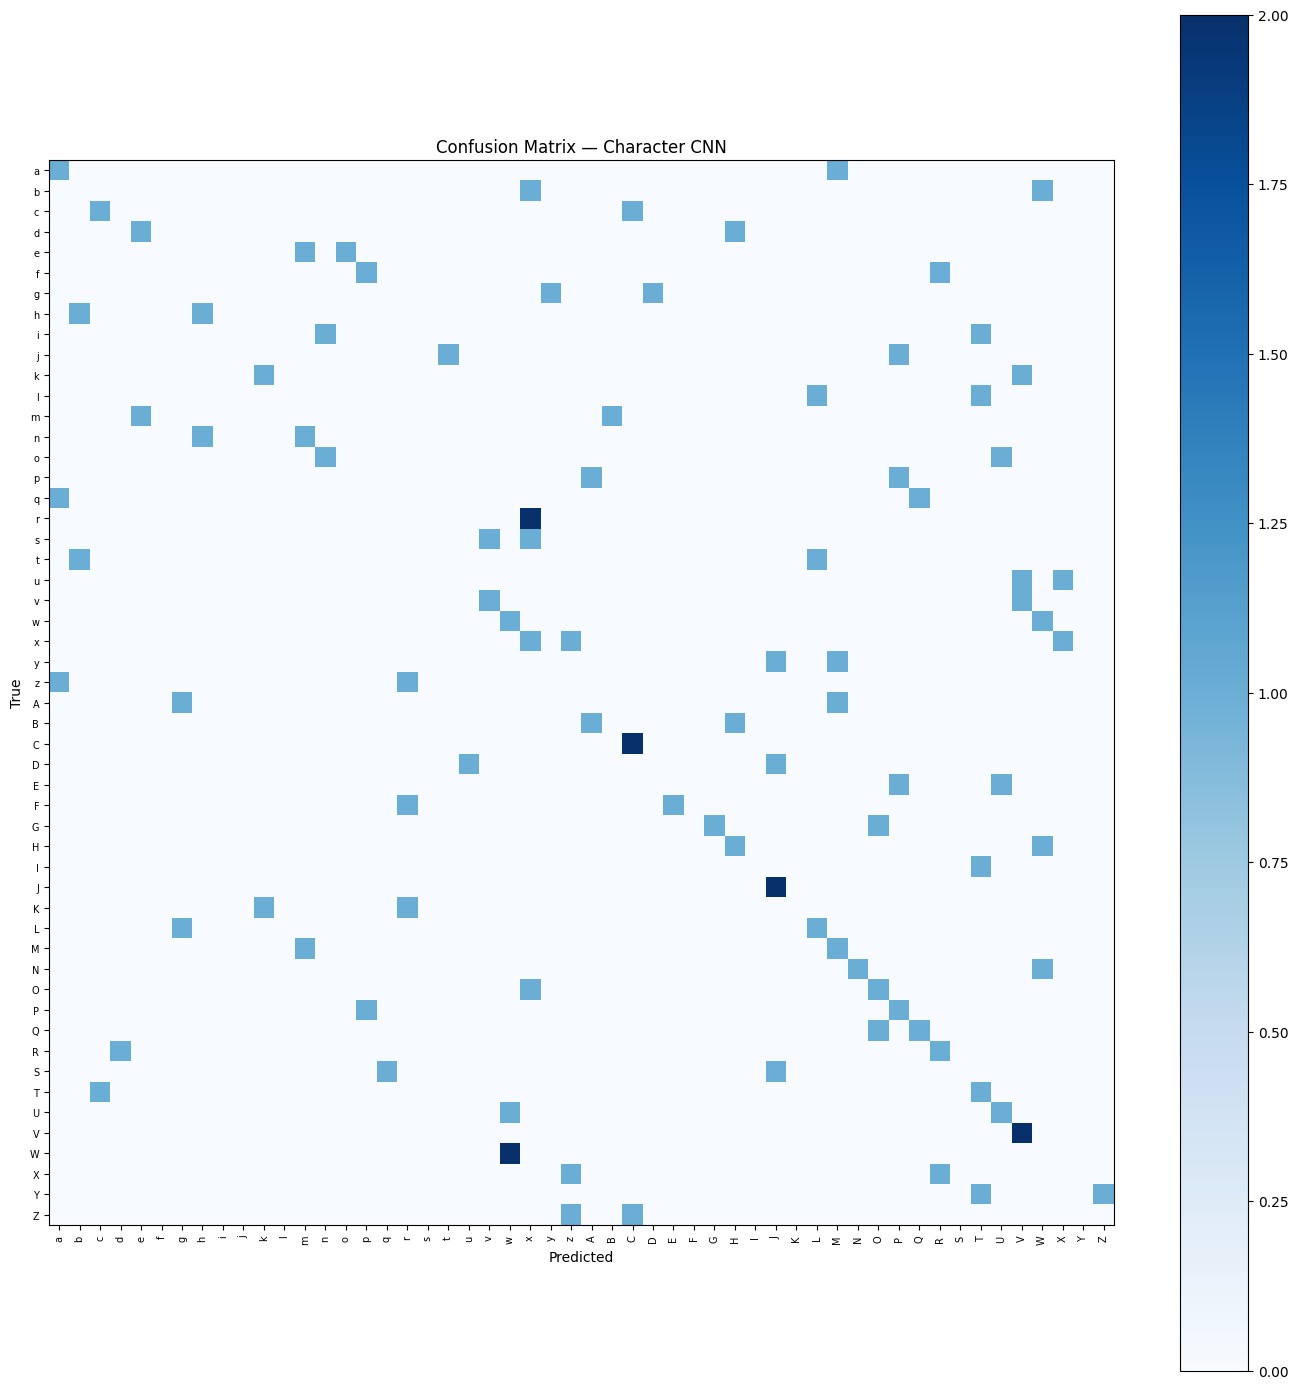

✓ Confusion matrix saved to /content/drive/MyDrive/SmartPrescription/models/cnn_character/confusion_matrix.png
  Look for bright off-diagonal cells — those are your most-confused letter pairs
  (commonly: O/0, I/l/1, U/V, or lowercase pairs like a/o)


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Load best model for final evaluation
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'best_model.pt')))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

readable_names = [idx_to_char[i] for i in range(len(class_names))]

report = classification_report(
    all_labels, all_preds, target_names=readable_names,
    zero_division=0, output_dict=True,
)
print(classification_report(all_labels, all_preds, target_names=readable_names, zero_division=0))

# Save report to Drive
import json
with open(os.path.join(OUTPUT_DIR, 'eval_report.json'), 'w') as f:
    json.dump(report, f, indent=2)

# Confusion matrix (large — save as image rather than trying to read inline)
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 14))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(readable_names)))
ax.set_yticks(range(len(readable_names)))
ax.set_xticklabels(readable_names, fontsize=7, rotation=90)
ax.set_yticklabels(readable_names, fontsize=7)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Character CNN')
plt.colorbar(im)
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150)
plt.show()
print(f'✓ Confusion matrix saved to {cm_path}')
print('  Look for bright off-diagonal cells — those are your most-confused letter pairs')
print('  (commonly: O/0, I/l/1, U/V, or lowercase pairs like a/o)')

---
## 9. Save Final Model + Label Map

In [11]:
# Save label map so local inference code knows index -> character
label_map_path = os.path.join(OUTPUT_DIR, 'label_map.json')
with open(label_map_path, 'w') as f:
    json.dump({
        'idx_to_char': idx_to_char,
        'class_to_idx': class_to_idx,
        'img_size': IMG_SIZE,
        'num_classes': len(class_names),
    }, f, indent=2)

# Save training history
with open(os.path.join(OUTPUT_DIR, 'train_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

print(f'✓ Saved to {OUTPUT_DIR}:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  {fname:<30} {size_kb:.1f} KB')
    else:
        print(f'  {fname}/')

✓ Saved to /content/drive/MyDrive/SmartPrescription/models/cnn_character:
  best_model.pt                  8611.3 KB
  checkpoints/
  confusion_matrix.png           71.0 KB
  eval_report.json               5.4 KB
  label_map.json                 1.8 KB
  train_history.json             2.4 KB


---
## 10. Zip & Download

In [12]:
import shutil

zip_path = '/content/drive/MyDrive/SmartPrescription/cnn_character.zip'
shutil.make_archive(
    base_name=zip_path.replace('.zip', ''),
    format='zip',
    root_dir=os.path.dirname(OUTPUT_DIR),
    base_dir=os.path.basename(OUTPUT_DIR),
)
size_mb = os.path.getsize(zip_path) / 1e6
print(f'✓ Zipped → {zip_path}  ({size_mb:.1f} MB)')
print()
print('Next steps:')
print('  1. Download cnn_character.zip from your Google Drive')
print('  2. Extract it locally')
print('  3. Place the contents in:  Smart-Prescription-NLP/models/cnn_character/')
print('     (should contain: best_model.pt, label_map.json, eval_report.json,')
print('      confusion_matrix.png, checkpoints/)')
print('  4. Ask Claude Code to implement CNNCharacterModel in src/models/cnn_infer.py')
print('     using this saved model — the OCRModel interface placeholder is already there.')

✓ Zipped → /content/drive/MyDrive/SmartPrescription/cnn_character.zip  (212.5 MB)

Next steps:
  1. Download cnn_character.zip from your Google Drive
  2. Extract it locally
  3. Place the contents in:  Smart-Prescription-NLP/models/cnn_character/
     (should contain: best_model.pt, label_map.json, eval_report.json,
      confusion_matrix.png, checkpoints/)
  4. Ask Claude Code to implement CNNCharacterModel in src/models/cnn_infer.py
     using this saved model — the OCRModel interface placeholder is already there.


---
## Notes for Next Steps

### If validation accuracy is low (< 85%)
| Issue | Fix |
|---|---|
| Too few images per letter | Aim for 200+ per class minimum, 500+ ideally |
| Confusion matrix shows specific pairs confused | Check those letters' samples for mislabeling or genuinely ambiguous handwriting |
| Overfitting (train acc high, val acc low) | Increase dropout, add more data, reduce NUM_EPOCHS |
| Underfitting (both low) | Train longer, check images aren't corrupted/blank |

### After downloading — implementing CNNCharacterModel locally
The `OCRModel` interface placeholder in `src/models/cnn_infer.py` (from earlier work)
is where this trained model plugs in. Give Claude Code this prompt:

```
I've trained the CNN character model and placed the output in
models/cnn_character/ (best_model.pt, label_map.json). Implement
CNNCharacterModel in src/models/cnn_infer.py to match the OCRModel interface:
load the PyTorch model + label map, and implement recognize_line() by
segmenting the input line image into individual characters (reuse
src/preprocessing/segment_characters.py logic), classifying each with the
CNN, and joining the predicted characters into a word/line string with an
averaged confidence score across characters.
```

This is exactly the plug-in point the interface was built for back in the
OCR restructuring step — no changes needed anywhere else.